In [ ]:
# ============================
# ✅ One-Cell Dataset Preprocessing for Colab (FINAL VERSION)
# ============================

from pathlib import Path
from PIL import Image
import numpy as np
import random, shutil, os

# ---------- ✅ EDITED FOR YOU ----------
INPUT_DIR  = "/content/dataset/Original Dataset"   # ✅ your extracted dataset
OUTPUT_DIR = "/content/ProcessedDataset"           # where processed files go

SIZE        = 224       # Resize to 224x224
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10      # 10% val, 10% test
SEED        = 42
SAVE_NPZ    = False     # Save train/val/test arrays too?
GRAYSCALE   = False     # Use RGB (True only if you want 1-channel MRI)
CLEAN_OUTPUT = True
# ----------------------------------------

ALLOWED_EXTS = {".jpg",".jpeg",".png",".bmp",".tif",".tiff",".webp"}

def is_image(p: Path) -> bool:
    return p.is_file() and p.suffix.lower() in ALLOWED_EXTS

def open_and_resize(src: Path, size: int, grayscale: bool):
    img = Image.open(src)
    img = img.convert("L" if grayscale else "RGB")
    img = img.resize((size, size), Image.BILINEAR)
    return img

def save_jpeg(img: Image.Image, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    dst = dst.with_suffix(".jpg")
    img.save(dst, quality=95)

def collect_images(input_dir: Path):
    classes = {}
    for cls_dir in sorted([p for p in input_dir.iterdir() if p.is_dir()]):
        imgs = [p for p in cls_dir.rglob("*") if is_image(p)]
        if imgs:
            classes[cls_dir.name] = imgs
    if not classes:
        raise RuntimeError(f"No images found in {input_dir}")
    return classes

def split_list(items, train_ratio, val_ratio, seed=42):
    r = random.Random(seed)
    r.shuffle(items)
    n = len(items)
    n_train = int(n * train_ratio)
    n_val   = int(n * val_ratio)
    return items[:n_train], items[n_train:n_train+n_val], items[n_train+n_val:]

def export_all(class_to_imgs, output_dir: Path, size: int, ratios, seed=42, save_npz=False, grayscale=False):
    train_ratio, val_ratio = ratios
    label_map = {cls: i for i, cls in enumerate(sorted(class_to_imgs.keys()))}

    counts = {"train": {}, "val": {}, "test": {}}
    npz = None
    if save_npz:
        npz = {
            "train": {"X": [], "y": []},
            "val":   {"X": [], "y": []},
            "test":  {"X": [], "y": []},
        }

    for cls, paths in class_to_imgs.items():
        tr, va, te = split_list(paths, train_ratio, val_ratio, seed)

        for split_name, split_paths in (("train", tr), ("val", va), ("test", te)):
            counts[split_name][cls] = 0
            for src in split_paths:
                try:
                    img = open_and_resize(src, size, grayscale)
                    dst = output_dir / split_name / cls / src.stem
                    save_jpeg(img, dst)
                    counts[split_name][cls] += 1

                    if save_npz:
                        arr = np.asarray(img, dtype=np.float32) / 255.0
                        if grayscale:
                            arr = np.expand_dims(arr, axis=-1)
                        npz[split_name]["X"].append(arr)
                        npz[split_name]["y"].append(label_map[cls])
                except Exception as e:
                    print(f"[WARN] Skipped {src}: {e}")

    (output_dir / "labels.txt").write_text(
        "\n".join(f"{i}\t{cls}" for cls, i in label_map.items()),
        encoding="utf-8"
    )

    if save_npz:
        for split in ("train","val","test"):
            X = np.stack(npz[split]["X"],axis=0) if npz[split]["X"] else np.empty((0,))
            y = np.array(npz[split]["y"]) if npz[split]["y"] else np.empty((0,))
            np.savez_compressed(output_dir/f"{split}.npz", X=X, y=y)

    return counts, label_map


# -------- ✅ RUNNING --------

input_dir = Path(INPUT_DIR)
output_dir = Path(OUTPUT_DIR)

if not input_dir.exists():
    raise FileNotFoundError(f"INPUT_DIR not found: {INPUT_DIR}")

if CLEAN_OUTPUT and output_dir.exists():
    shutil.rmtree(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

classes = collect_images(input_dir)
print("✅ Classes found:", list(classes.keys()))

counts, labels = export_all(
    classes, output_dir, SIZE, (TRAIN_RATIO, VAL_RATIO),
    seed=SEED, save_npz=SAVE_NPZ, grayscale=GRAYSCALE
)

print("\n✅ DONE — SUMMARY")
for split in ("train","val","test"):
    for cls, n in counts[split].items():
        print(f"{split:<5} | {cls:<12} : {n}")

print("\nLabel map:", labels)
print(f"\n📁 Processed dataset saved to: {OUTPUT_DIR}")


✅ Classes found: ['Non-Stone', 'Stone']

✅ DONE — SUMMARY
train | Non-Stone    : 1429
train | Stone        : 1261
val   | Non-Stone    : 178
val   | Stone        : 157
test  | Non-Stone    : 180
test  | Stone        : 159

Label map: {'Non-Stone': 0, 'Stone': 1}

📁 Processed dataset saved to: /content/ProcessedDataset


In [ ]:
!unzip "/content/OriginalDataset-20251107T172703Z-1-001.zip" -d "/content/dataset"


Archive:  /content/OriginalDataset-20251107T172703Z-1-001.zip
  inflating: /content/dataset/Original Dataset/.DS_Store  
  inflating: /content/dataset/Original Dataset/Non-Stone/998.jpg  
  inflating: /content/dataset/Original Dataset/Non-Stone/995.jpg  
  inflating: /content/dataset/Original Dataset/Non-Stone/kkkk.jpg  
  inflating: /content/dataset/Original Dataset/Non-Stone/994.jpg  
  inflating: /content/dataset/Original Dataset/Non-Stone/nnnn.jpg  
  inflating: /content/dataset/Original Dataset/Non-Stone/997.jpg  
  inflating: /content/dataset/Original Dataset/Non-Stone/mmmm.jpg  
  inflating: /content/dataset/Original Dataset/Non-Stone/996.jpg  
  inflating: /content/dataset/Original Dataset/Non-Stone/lll.jpg  
  inflating: /content/dataset/Original Dataset/Non-Stone/953.jpg  
  inflating: /content/dataset/Original Dataset/Non-Stone/974.jpg  
  inflating: /content/dataset/Original Dataset/Non-Stone/993.jpg  
  inflating: /content/dataset/Original Dataset/Non-Stone/881.jpg  
  inf

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

DATA_PATH = Path("/content/ProcessedDataset")
CLASSES = ["Non-Stone", "Stone"]


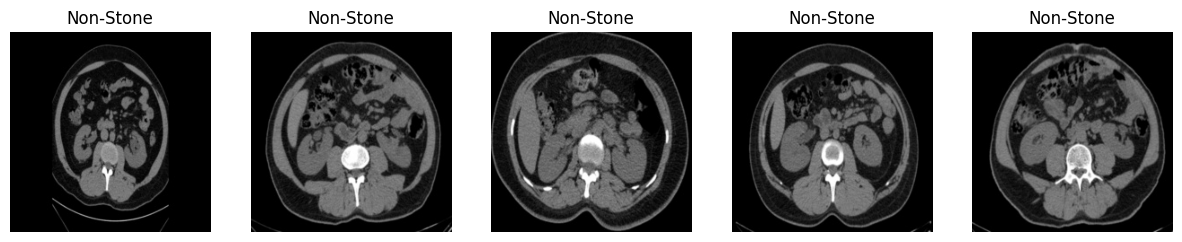

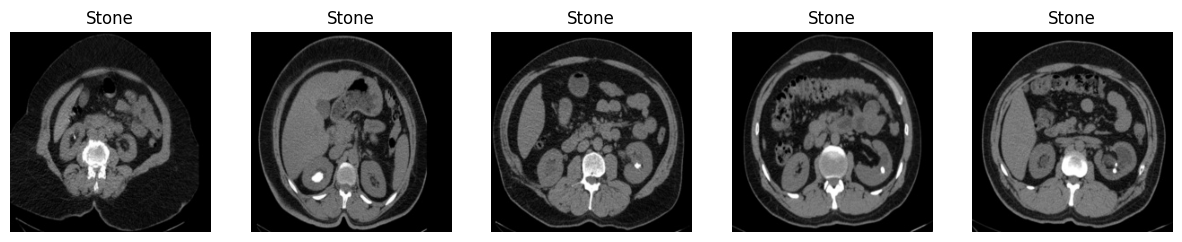

In [ ]:
def show_random_images(class_name, n=5):
    paths = list((DATA_PATH / "train" / class_name).glob("*.jpg"))
    samples = random.sample(paths, n)

    plt.figure(figsize=(15, 3))
    for i, img_path in enumerate(samples):
        img = Image.open(img_path)
        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(class_name)
        plt.axis('off')
    plt.show()

for cls in CLASSES:
    show_random_images(cls, n=5)


In [ ]:
import numpy as np

#Image statisitcs, looking at shape and statistics of non stone vs stone

def get_dataset_stats():
    stats = {}

    for cls in CLASSES:
        imgs = list((DATA_PATH / "train" / cls).glob("*.jpg"))
        pixels = []

        for img_path in imgs[:300]:  # limit for speed
            img = np.array(Image.open(img_path))
            pixels.append(img)

        pixels = np.stack(pixels)
        stats[cls] = {
            "mean_pixel": np.mean(pixels),
            "std_pixel": np.std(pixels),
            "min_pixel": np.min(pixels),
            "max_pixel": np.max(pixels)
        }

    return stats

stats = get_dataset_stats()
stats


{'Non-Stone': {'mean_pixel': np.float64(36.02934723107993),
  'std_pixel': np.float64(50.181886201908256),
  'min_pixel': np.uint8(0),
  'max_pixel': np.uint8(255)},
 'Stone': {'mean_pixel': np.float64(36.510021524234695),
  'std_pixel': np.float64(49.98045833283637),
  'min_pixel': np.uint8(0),
  'max_pixel': np.uint8(255)}}

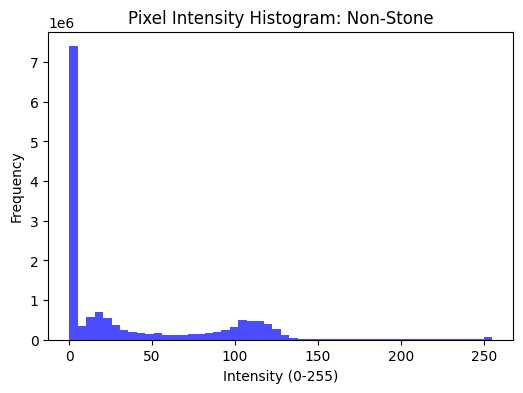

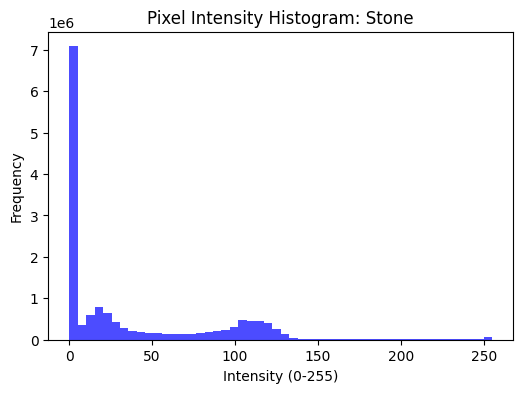

In [ ]:
#Look at the intensisity of the pixels in the histograms
#This is often used in radiology research papers.

def plot_histograms(cls):
    imgs = list((DATA_PATH / "train" / cls).glob("*.jpg"))

    all_pixels = []
    for img_path in imgs[:300]:
        img = np.array(Image.open(img_path).convert("L"))
        all_pixels.append(img.flatten())

    all_pixels = np.concatenate(all_pixels)

    plt.figure(figsize=(6,4))
    plt.hist(all_pixels, bins=50, alpha=0.7, color='blue')
    plt.title(f"Pixel Intensity Histogram: {cls}")
    plt.xlabel("Intensity (0-255)")
    plt.ylabel("Frequency")
    plt.show()

for cls in CLASSES:
    plot_histograms(cls)


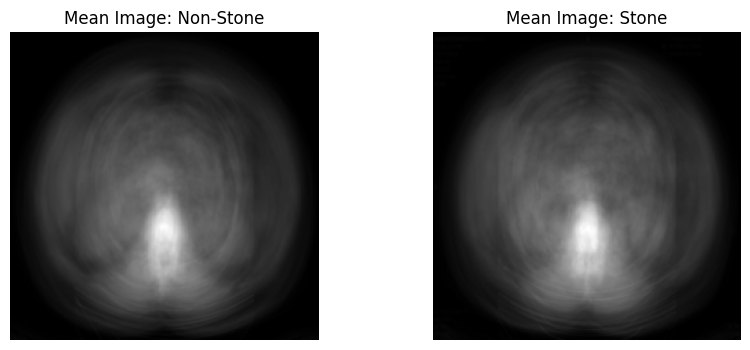

In [ ]:
#Here we will find the avarages of how non stone vs stone images looks like,
#go through each pixel of a certain class (stone vs non-stone) and avarage it to find the avarage image


def compute_mean_image(cls):
    imgs = list((DATA_PATH / "train" / cls).glob("*.jpg"))
    arrs = []

    for img_path in imgs[:300]:
        img = np.array(Image.open(img_path).convert("L"), dtype=np.float32)
        arrs.append(img)

    mean_img = np.mean(arrs, axis=0)
    return mean_img

mean_non = compute_mean_image("Non-Stone")
mean_stone = compute_mean_image("Stone")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(mean_non, cmap='gray'); plt.title("Mean Image: Non-Stone"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(mean_stone, cmap='gray'); plt.title("Mean Image: Stone"); plt.axis('off')
plt.show()


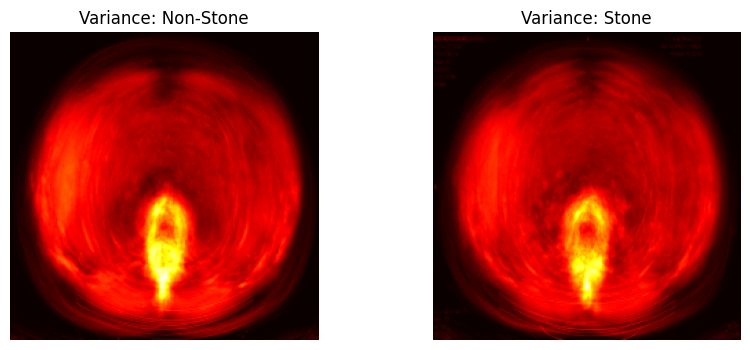

In [ ]:
#varience of images, look at a specific class and be able to know where differences occur in each (stone vs no stone)

def compute_variance_image(cls):
    imgs = list((DATA_PATH / "train" / cls).glob("*.jpg"))
    arrs = []

    for img_path in imgs[:300]:
        img = np.array(Image.open(img_path).convert("L"), dtype=np.float32)
        arrs.append(img)

    var_img = np.var(arrs, axis=0)
    return var_img

var_non = compute_variance_image("Non-Stone")
var_stone = compute_variance_image("Stone")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(var_non, cmap='hot'); plt.title("Variance: Non-Stone"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(var_stone, cmap='hot'); plt.title("Variance: Stone"); plt.axis('off')
plt.show()


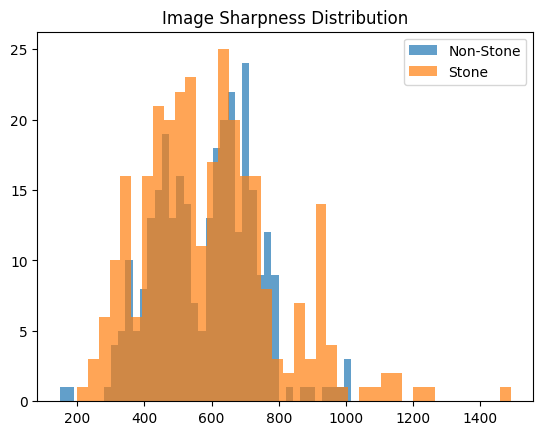

In [ ]:
#used Laplacian Focus Score to tell how sharp the boundaires
#of kidey stones are and being able to locate when a kidey stone is found

import cv2

def compute_sharpness(cls):
    imgs = list((DATA_PATH / "train" / cls).glob("*.jpg"))
    sharpness_values = []

    for img_path in imgs[:300]:
        img = cv2.imread(str(img_path), 0)
        sharp = cv2.Laplacian(img, cv2.CV_64F).var()
        sharpness_values.append(sharp)

    return sharpness_values

sharp_non = compute_sharpness("Non-Stone")
sharp_stone = compute_sharpness("Stone")

plt.hist(sharp_non, bins=40, alpha=0.7, label="Non-Stone")
plt.hist(sharp_stone, bins=40, alpha=0.7, label="Stone")
plt.legend()
plt.title("Image Sharpness Distribution")
plt.show()


Device: cuda
Classes: ['Non-Stone', 'Stone']
Train counts: {'Non-Stone': 1429, 'Stone': 1261}
Val counts:   {'Non-Stone': 178, 'Stone': 157}
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 194MB/s]


[Head] Epoch 01/6 | train 0.6067/0.676 | val 0.5505/0.716
[Head] Epoch 02/6 | train 0.5280/0.743 | val 0.5098/0.758
[Head] Epoch 03/6 | train 0.4859/0.771 | val 0.4937/0.758
[Head] Epoch 04/6 | train 0.4557/0.795 | val 0.5000/0.743
[Head] Epoch 05/6 | train 0.4467/0.799 | val 0.5104/0.749
[Head] Epoch 06/6 | train 0.4449/0.792 | val 0.5055/0.740
[FT  ] Epoch 01/8 | train 0.3780/0.837 | val 0.4055/0.815
[FT  ] Epoch 02/8 | train 0.3091/0.874 | val 0.3492/0.875
[FT  ] Epoch 03/8 | train 0.2507/0.895 | val 0.3025/0.878
[FT  ] Epoch 04/8 | train 0.2234/0.912 | val 0.2974/0.875
[FT  ] Epoch 05/8 | train 0.1808/0.929 | val 0.2635/0.881
[FT  ] Epoch 06/8 | train 0.1613/0.937 | val 0.2415/0.896
[FT  ] Epoch 07/8 | train 0.1526/0.944 | val 0.1986/0.925
[FT  ] Epoch 08/8 | train 0.1318/0.947 | val 0.1934/0.931


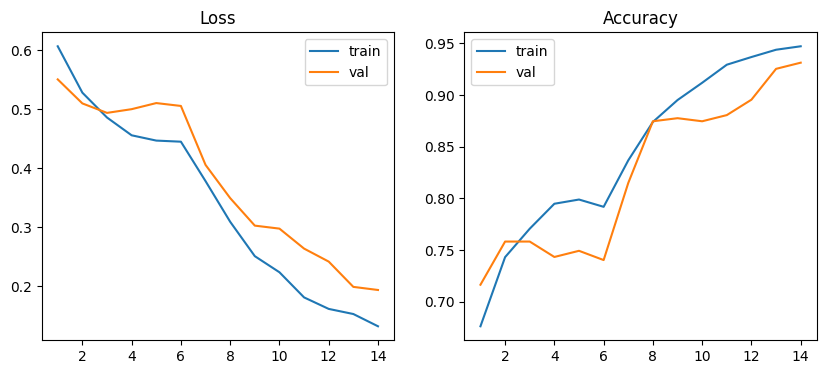

Validation Confusion Matrix:
 [[166  12]
 [ 11 146]]

Validation Classification Report:
               precision    recall  f1-score   support

   Non-Stone       0.94      0.93      0.94       178
       Stone       0.92      0.93      0.93       157

    accuracy                           0.93       335
   macro avg       0.93      0.93      0.93       335
weighted avg       0.93      0.93      0.93       335



In [ ]:
#Training!!
# ===== ResNet50 Transfer Learning: Train + Validation ONLY =====
# Assumes folder structure created by your preprocessor:
# /content/ProcessedDataset/train/<class>/*.jpg
# /content/ProcessedDataset/val/<class>/*.jpg

# --- Imports ---
import os, copy, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix, classification_report

# --- Config ---
DATA_DIR   = "/content/ProcessedDataset"
IMG_SIZE   = 224
BATCH_SIZE = 32
SEED       = 42
LR_HEAD    = 3e-3   # phase 1 (head only)
LR_FT      = 3e-5   # phase 2 (fine-tune last block)
EPOCHS_HEAD= 6
EPOCHS_FT  = 8

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# --- Transforms (match common ImageNet normalization) ---
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(7),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])
val_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# --- Datasets/Loaders (train + val only) ---
data_root = Path(DATA_DIR)
assert (data_root/"train").exists() and (data_root/"val").exists(), "Train/val folders not found."

image_datasets = {
    "train": datasets.ImageFolder(data_root/"train", transform=train_tfms),
    "val":   datasets.ImageFolder(data_root/"val",   transform=val_tfms),
}
dataloaders = {
    k: DataLoader(v, batch_size=BATCH_SIZE, shuffle=(k=="train"), num_workers=2, pin_memory=True)
    for k,v in image_datasets.items()
}
class_names = image_datasets["train"].classes
num_classes = len(class_names)
print("Classes:", class_names)

# --- Show class counts (sanity check) ---
def count_images(dset):
    counts = {}
    for cls, idx in dset.class_to_idx.items():
        n = sum(1 for p,_ in dset.samples if _ == idx)
        counts[cls] = n
    return counts
print("Train counts:", count_images(image_datasets["train"]))
print("Val counts:  ", count_images(image_datasets["val"]))

# --- Build ResNet50 ---
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_feats = model.fc.in_features
model.fc = nn.Linear(in_feats, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss, running_corrects, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        preds = out.argmax(1)
        running_loss += loss.item() * x.size(0)
        running_corrects += (preds == y).sum().item()
        n += x.size(0)
    return running_loss/n, running_corrects/n

@torch.no_grad()
def eval_one_epoch(model, loader):
    model.eval()
    running_loss, running_corrects, n = 0.0, 0, 0
    all_y, all_pred = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = criterion(out, y)
        preds = out.argmax(1)
        running_loss += loss.item() * x.size(0)
        running_corrects += (preds == y).sum().item()
        n += x.size(0)
        all_y.append(y.cpu())
        all_pred.append(preds.cpu())
    all_y = torch.cat(all_y).numpy()
    all_pred = torch.cat(all_pred).numpy()
    return running_loss/n, running_corrects/n, all_y, all_pred

def freeze_backbone_except_fc(model):
    for name, p in model.named_parameters():
        p.requires_grad = name.startswith("fc.")
def unfreeze_last_block_and_fc(model):
    for name, p in model.named_parameters():
        p.requires_grad = name.startswith("layer4.") or name.startswith("fc.")

# --- Phase 1: Train classifier head only ---
freeze_backbone_except_fc(model)
optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR_HEAD, weight_decay=1e-4)

hist = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}
best_w = copy.deepcopy(model.state_dict()); best_acc = 0.0

for epoch in range(1, EPOCHS_HEAD+1):
    tr_loss, tr_acc = train_one_epoch(model, dataloaders["train"], optimizer)
    va_loss, va_acc, _, _ = eval_one_epoch(model, dataloaders["val"])
    hist["train_loss"].append(tr_loss); hist["train_acc"].append(tr_acc)
    hist["val_loss"].append(va_loss);   hist["val_acc"].append(va_acc)
    if va_acc > best_acc:
        best_acc = va_acc; best_w = copy.deepcopy(model.state_dict())
    print(f"[Head] Epoch {epoch:02d}/{EPOCHS_HEAD} | train {tr_loss:.4f}/{tr_acc:.3f} | val {va_loss:.4f}/{va_acc:.3f}")

# --- Phase 2: Fine-tune last block + fc ---
unfreeze_last_block_and_fc(model)
optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR_FT, weight_decay=1e-4)

for epoch in range(1, EPOCHS_FT+1):
    tr_loss, tr_acc = train_one_epoch(model, dataloaders["train"], optimizer)
    va_loss, va_acc, _, _ = eval_one_epoch(model, dataloaders["val"])
    hist["train_loss"].append(tr_loss); hist["train_acc"].append(tr_acc)
    hist["val_loss"].append(va_loss);   hist["val_acc"].append(va_acc)
    if va_acc > best_acc:
        best_acc = va_acc; best_w = copy.deepcopy(model.state_dict())
    print(f"[FT  ] Epoch {epoch:02d}/{EPOCHS_FT} | train {tr_loss:.4f}/{tr_acc:.3f} | val {va_loss:.4f}/{va_acc:.3f}")

# Load best validation weights
model.load_state_dict(best_w)

# --- Curves ---
xs = np.arange(1, len(hist["train_loss"])+1)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(xs, hist["train_loss"], label="train"); plt.plot(xs, hist["val_loss"], label="val"); plt.title("Loss"); plt.legend()
plt.subplot(1,2,2); plt.plot(xs, hist["train_acc"],  label="train"); plt.plot(xs, hist["val_acc"],  label="val"); plt.title("Accuracy"); plt.legend()
plt.show()

# --- Validation evaluation (confusion matrix + report) ---
_, _, y_val, y_val_pred = eval_one_epoch(model, dataloaders["val"])
cm = confusion_matrix(y_val, y_val_pred)
print("Validation Confusion Matrix:\n", cm)
print("\nValidation Classification Report:\n",
      classification_report(y_val, y_val_pred, target_names=class_names))
